In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("EDA_PROJECT_MAIN.csv")  

In [3]:
df

,Unnamed: 0,Product_name,Price,Ram,Rating,Count_Rating,Review,Inch,Battery,Colour,Android_IOS,Brand
0,0,REDMI Pad Pro 5G,22999,8,4.4,6726,432,12.1,10000,Graphite Grey,Android 14,REDMI
1,1,Samsung Galaxy Tab A9+,21999,8,4.5,38465,1473,11.0,7040,Graphite,Android 12,Samsung
2,2,POCO Pad 5G,21999,8,4.4,9167,749,12.1,10000,Cobalt Blue,Android 14,POCO
3,3,Samsung Galaxy Tab A9,15999,4,4.3,2393,102,8.7,5100,Navy,Android 12,Samsung
4,4,Samsung Galaxy Tab A9+,24999,8,4.5,38465,1473,11.0,7040,Navy,Android 12,Samsung
...,...,...,...,...,...,...,...,...,...,...,...,...
400,400,Samsung Galaxy Tab A9+,16999,4,4.5,38465,1473,11.0,7040,GRAPHITE,Android 12,Samsung
401,401,Samsung Galaxy Tab A9+,17999,8,4.5,38465,1473,11.0,7040,Silver,Android 12,Samsung
402,402,Samsung Galaxy Tab A9+,16999,8,4.5,38465,1473,11.0,7040,Navy,Android 12,Samsung
403,403,Samsung Galaxy Tab A9,12490,4,4.3,2393,102,8.7,5100,Graphite,Android 12,Samsung


In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df

,Product_name,Price,Ram,Rating,Count_Rating,Review,Inch,Battery,Colour,Android_IOS,Brand
0,REDMI Pad Pro 5G,22999,8,4.4,6726,432,12.1,10000,Graphite Grey,Android 14,REDMI
1,Samsung Galaxy Tab A9+,21999,8,4.5,38465,1473,11.0,7040,Graphite,Android 12,Samsung
2,POCO Pad 5G,21999,8,4.4,9167,749,12.1,10000,Cobalt Blue,Android 14,POCO
3,Samsung Galaxy Tab A9,15999,4,4.3,2393,102,8.7,5100,Navy,Android 12,Samsung
4,Samsung Galaxy Tab A9+,24999,8,4.5,38465,1473,11.0,7040,Navy,Android 12,Samsung
...,...,...,...,...,...,...,...,...,...,...,...
400,Samsung Galaxy Tab A9+,16999,4,4.5,38465,1473,11.0,7040,GRAPHITE,Android 12,Samsung
401,Samsung Galaxy Tab A9+,17999,8,4.5,38465,1473,11.0,7040,Silver,Android 12,Samsung
402,Samsung Galaxy Tab A9+,16999,8,4.5,38465,1473,11.0,7040,Navy,Android 12,Samsung
403,Samsung Galaxy Tab A9,12490,4,4.3,2393,102,8.7,5100,Graphite,Android 12,Samsung


## UNIVARIATE ANALYSIS – NON VISUALIZATION

### Numerical Columns 


In [6]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].head()

,Price,Ram,Rating,Count_Rating,Review,Inch,Battery
0,22999,8,4.4,6726,432,12.1,10000
1,21999,8,4.5,38465,1473,11.0,7040
2,21999,8,4.4,9167,749,12.1,10000
3,15999,4,4.3,2393,102,8.7,5100
4,24999,8,4.5,38465,1473,11.0,7040


## Summary Statistics

In [7]:
df[num_cols].describe()

,Price,Ram,Rating,Count_Rating,Review,Inch,Battery
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,76646.780247,8.343210,4.514321,6265.681481,380.424691,11.178123,7593.903704
std,53473.725730,3.593618,0.250924,11175.887571,613.572926,1.609181,2151.910308
min,5499.000000,2.000000,3.000000,0.000000,0.000000,7.900000,0.000000
25%,33490.000000,6.000000,4.500000,155.000000,12.000000,10.400000,7040.000000
50%,70199.000000,8.000000,4.600000,1066.000000,108.000000,11.000000,7606.000000
75%,99839.000000,12.000000,4.600000,5592.000000,432.000000,12.400000,8400.000000
max,259900.000000,16.000000,4.800000,56942.000000,3686.000000,14.600000,11600.000000


In [18]:
df.describe(include="object")

,Product_name,Colour,Android_IOS,Brand
count,405,405,405,405
unique,59,50,24,15
top,Apple iPad Pro 2021,Silver,Android 12,Apple
freq,31,93,74,201


## Missing Values

In [8]:
df[num_cols].isnull().sum()

Price           0
Ram             0
Rating          0
Count_Rating    0
Review          0
Inch            0
Battery         0
dtype: int64

## Unique Value Count

In [9]:
df[num_cols].nunique()

Price           170
Ram               7
Rating           14
Count_Rating     64
Review           52
Inch             22
Battery          26
dtype: int64

## Checking Outlier Ranges

In [11]:
for col in num_cols:
    print(col, ":", df[col].min(), "-", df[col].max())

Price : 5499 - 259900
Ram : 2 - 16
Rating : 3.0 - 4.8
Count_Rating : 0 - 56942
Review : 0 - 3686
Inch : 7.9 - 14.6
Battery : 0 - 11600


### Categorical Columns

In [12]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols].head()

,Product_name,Colour,Android_IOS,Brand
0,REDMI Pad Pro 5G,Graphite Grey,Android 14,REDMI
1,Samsung Galaxy Tab A9+,Graphite,Android 12,Samsung
2,POCO Pad 5G,Cobalt Blue,Android 14,POCO
3,Samsung Galaxy Tab A9,Navy,Android 12,Samsung
4,Samsung Galaxy Tab A9+,Navy,Android 12,Samsung


## Category counts

In [13]:
for col in cat_cols:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: Product_name
Product_name
Apple iPad Pro 2021                                             31
Apple 2024 iPad Mini                                            24
Apple 2025 iPad Air                                             23
Apple 2025 iPad Pro                                             22
Samsung Galaxy Tab S9 FE+                                       19
Samsung Galaxy Tab A9+                                          17
Apple iPad                                                      16
Samsung Galaxy Tab S10 FE+                                      16
Samsung Galaxy Tab S9 FE                                        16
Apple iPad Air                                                  16
Apple 2024 iPad Pro                                             15
Apple 2024 iPad Air                                             14
Apple 2022 iPad Pro                                             12
Apple 2025 iPad                                                 12
Samsung Galaxy Tab S10 FE  

## Missing values

In [14]:
df[cat_cols].isnull().sum()

Product_name    0
Colour          0
Android_IOS     0
Brand           0
dtype: int64

### UNIVARIATE ANALYSIS – VISUALIZATION

## Numerical Columns

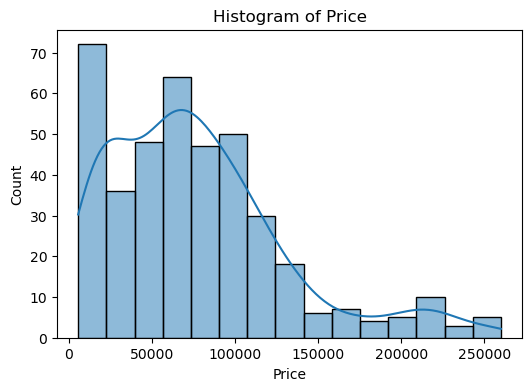

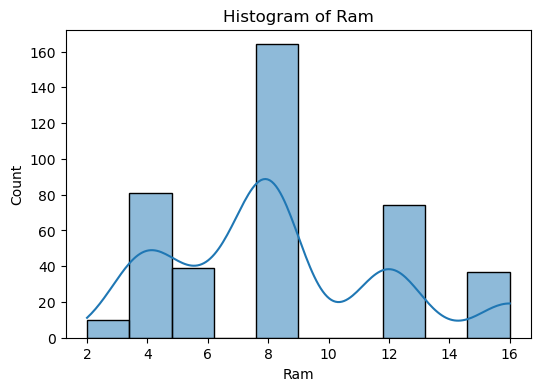

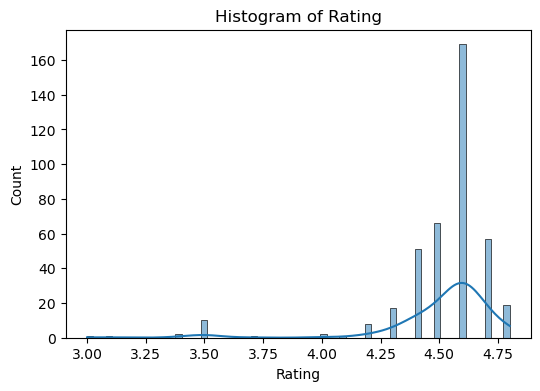

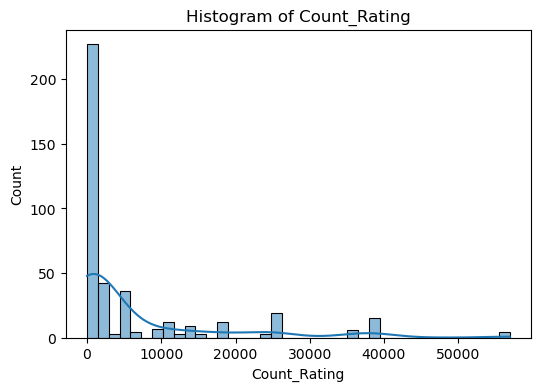

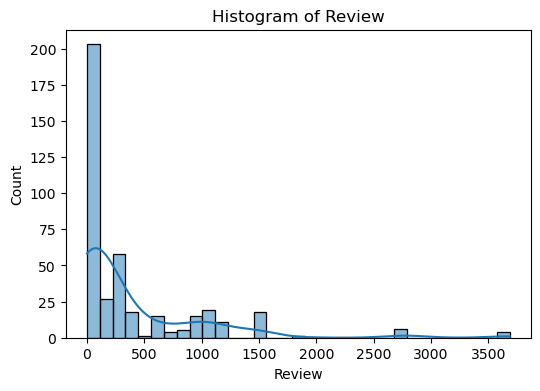

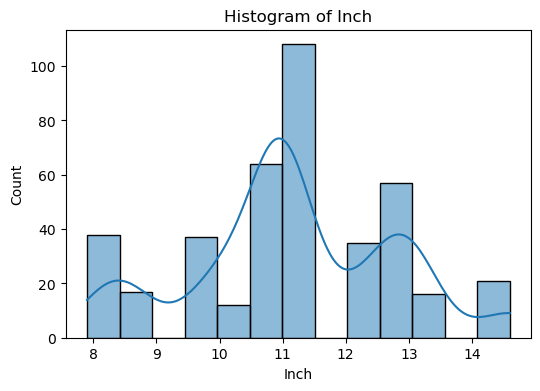

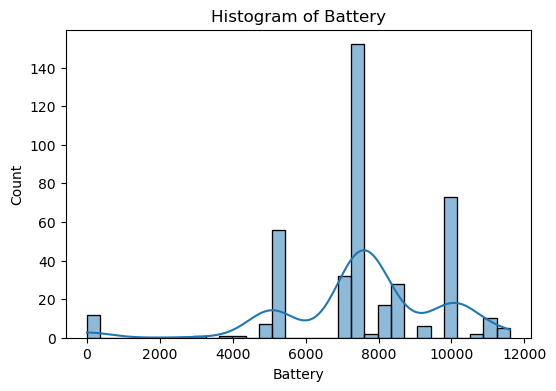

In [15]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

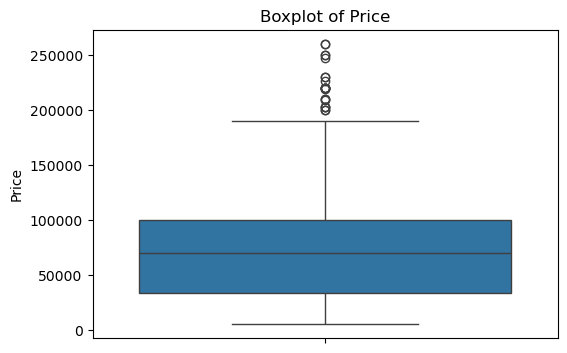

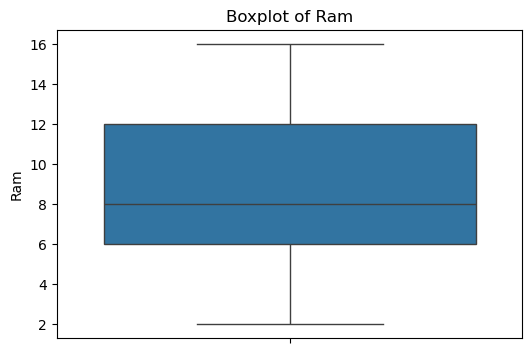

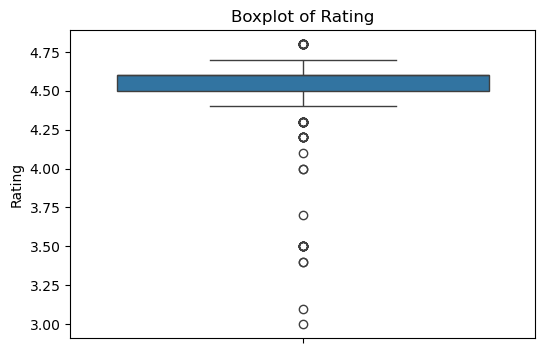

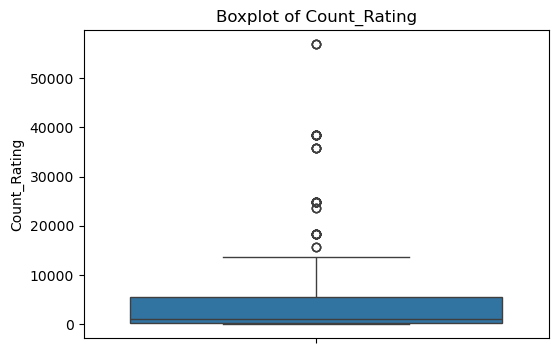

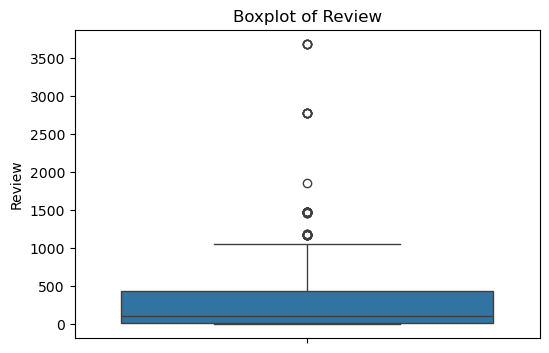

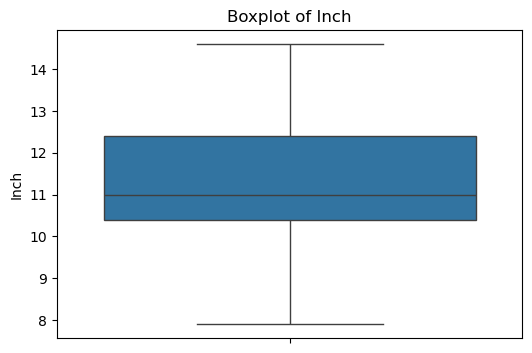

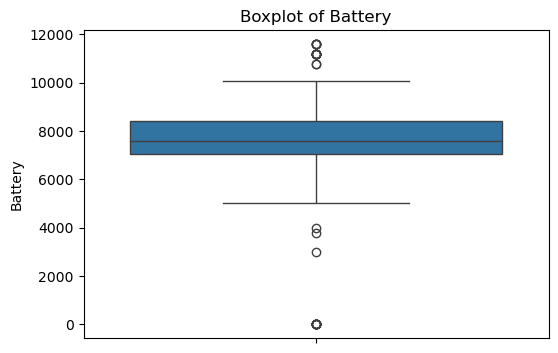

In [16]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Bivariate Analysis - Visualization

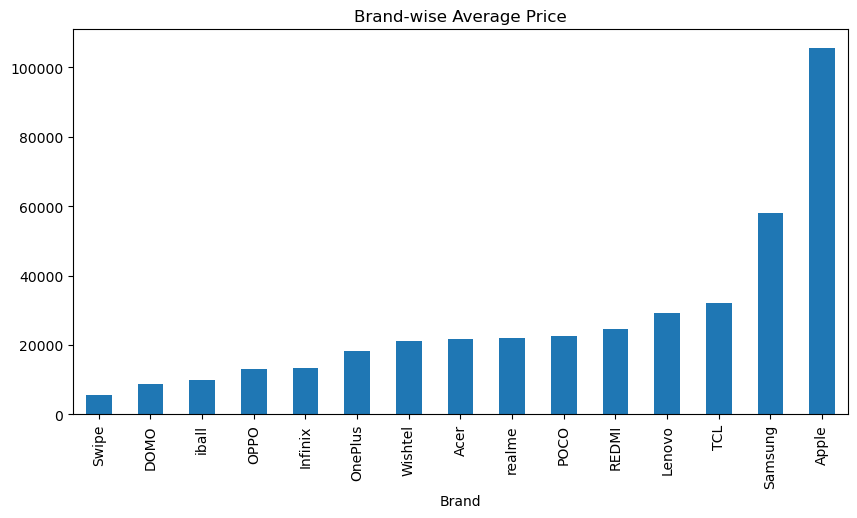

In [35]:
#Brand-wise Average Price
df.groupby('Brand')['Price'].mean().sort_values().plot(kind='bar', figsize=(10,5))
plt.title("Brand-wise Average Price")
plt.show()


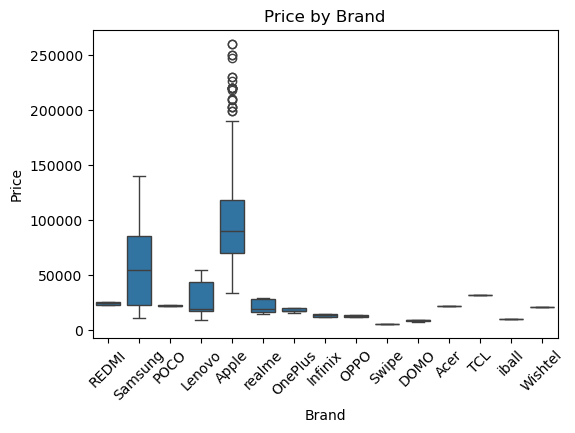

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Brand", y="Price", data=df)
plt.title("Price by Brand")
plt.xticks(rotation=45)
plt.show()

## Correlation Analysis

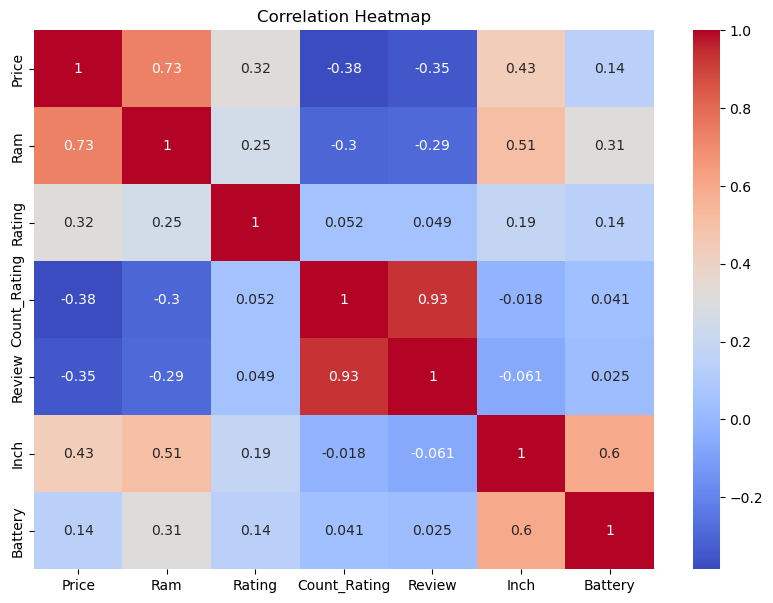

In [36]:
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Multivariate Analysis - Visualization 

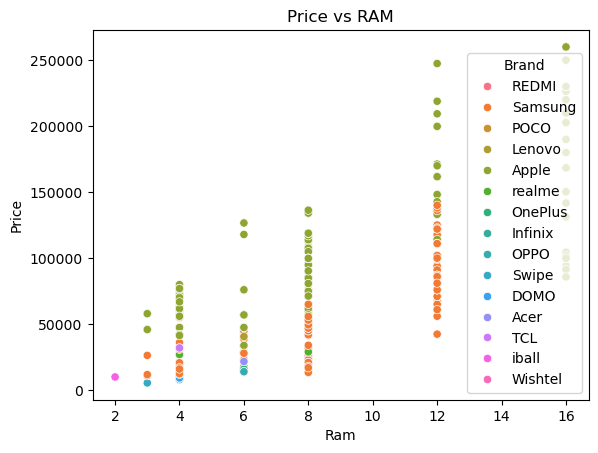

In [37]:
#Price vs RAM
sns.scatterplot(data=df, x="Ram", y="Price", hue="Brand")
plt.title("Price vs RAM")
plt.show()

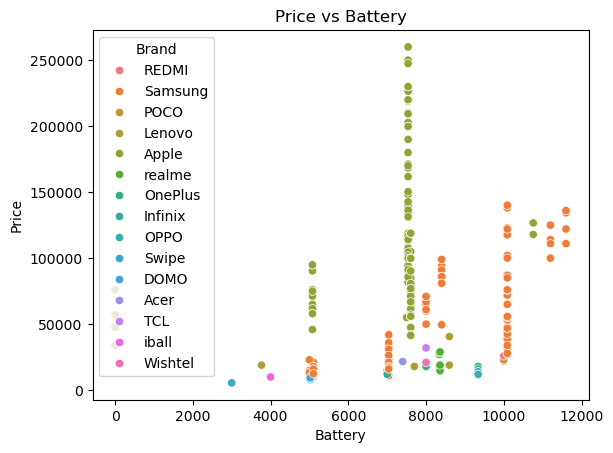

In [38]:
#Price vs Battery
sns.scatterplot(data=df, x="Battery", y="Price", hue="Brand")
plt.title("Price vs Battery")
plt.show()

In [17]:
#Summary & Insights
print("💡 Key Insights:\n")
print("1. Highest priced brand:", df.groupby('Brand')['Price'].mean().idxmax())
print("2. Top rated brand:", df.groupby('Brand')['Rating'].mean().idxmax())
print("3. Most listed brand:", df['Brand'].value_counts().idxmax())
print("4. Average tablet price =", df['Price'].mean())
print("5. Correlation strongest between Price & RAM / Battery / Reviews")

💡 Key Insights:

1. Highest priced brand: Apple
2. Top rated brand: Apple
3. Most listed brand: Apple
4. Average tablet price = 76646.78024691358
5. Correlation strongest between Price & RAM / Battery / Reviews
